# 策略一：配对交易（统计套利）

## 核心思路

寻找两只**协整**的股票。当它们的价差偏离历史均值超过阈值时，做空贵的、做多便宜的，赌价差回归。

## 实现步骤

1. **协整检验**：对候选股票对进行 Engle-Granger 协整检验
2. **对冲比率**：用 OLS 回归估计 β（对冲比率）
3. **计算价差**：`spread = log(A) - β × log(B)`
4. **Z-score 信号**：对价差做滚动标准化
5. **交易规则**：
   - 入场：|Z| > 2.0
   - 离场：|Z| < 0.5
   - 止损：|Z| > 3.5

## 数据

- 来源：`yfinance`，2015–2024 年日线
- 股票对：同行业龙头（KO/PEP、GS/MS、XOM/CVX 等）
- 训练期：2015–2019；样本外回测：2020–2024

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
# ── 参数设置 ──────────────────────────────────────────────
START = '2015-01-01'
END   = '2024-12-31'
ZSCORE_ENTRY     = 2.0    # Z-score 入场阈值
ZSCORE_EXIT      = 0.5    # Z-score 离场阈值（均值回归）
ZSCORE_STOP      = 3.5    # Z-score 止损阈值（价差继续扩大）
LOOKBACK         = 60     # 滚动均值/标准差的窗口（交易日）
TRANSACTION_COST = 0.001  # 单腿手续费（10 bps）

# 候选股票对：同行业龙头，历史上常有协整关系
CANDIDATE_PAIRS = [
    ('KO',   'PEP'),   # 可口可乐 vs 百事可乐（饮料）
    ('GS',   'MS'),    # 高盛 vs 摩根斯坦利（投资银行）
    ('XOM',  'CVX'),   # 埃克森美孚 vs 雪佛龙（石油巨头）
    ('MCD',  'YUM'),   # 麦当劳 vs 百胜餐饮（快餐）
    ('JPM',  'BAC'),   # 摩根大通 vs 美国银行（商业银行）
    ('AMZN', 'EBAY'),  # 亚马逊 vs eBay（电商）
    ('HD',   'LOW'),   # 家得宝 vs 劳氏（建材零售）
]

In [3]:
# --- Download data ---
all_tickers = list({t for pair in CANDIDATE_PAIRS for t in pair})
raw = yf.download(all_tickers, start=START, end=END, auto_adjust=True, progress=False)
prices = raw['Close'].dropna()
log_prices = np.log(prices)
print(f"Downloaded {len(prices)} days for {len(prices.columns)} tickers")
prices.tail(3)

Downloaded 2515 days for 14 tickers


Ticker,AMZN,BAC,CVX,EBAY,GS,HD,JPM,KO,LOW,MCD,MS,PEP,XOM,YUM
Date,,,,,,,,,,,,,,
2024-12-26,227.050003,43.296783,136.268219,62.639881,566.623352,382.967957,235.823608,60.361835,243.438721,286.480255,123.859863,145.284378,102.039894,132.805023
2024-12-27,223.750000,43.092686,136.287155,61.658222,561.700195,380.758118,233.912903,60.246075,242.374893,285.333557,122.631233,145.713242,102.030319,132.053085
2024-12-30,221.300003,42.674782,135.406967,60.921974,559.136475,377.433807,232.118576,59.840893,240.803589,281.427063,121.654137,144.598190,101.340408,130.383286


In [4]:
# ── 协整检验 ──────────────────────────────────────────────
def test_cointegration(s1, s2, significance=0.05):
    """Engle-Granger 协整检验，同时返回 OLS 对冲比率。"""
    score, pvalue, _ = coint(s1, s2)
    # OLS 估计对冲比率：s1 = α + β·s2
    X = sm.add_constant(s2)
    model = sm.OLS(s1, X).fit()
    beta = model.params.iloc[1]
    return pvalue, beta

print("样本内协整检验结果（训练期：2015–2019）")
print("-" * 55)
results = {}
train_end = '2019-12-31'
for a, b in CANDIDATE_PAIRS:
    if a not in log_prices.columns or b not in log_prices.columns:
        continue
    s1 = log_prices.loc[:train_end, a]
    s2 = log_prices.loc[:train_end, b]
    pval, beta = test_cointegration(s1, s2)
    cointed = pval < 0.05
    results[(a, b)] = {'pvalue': pval, 'beta': beta, 'cointegrated': cointed}
    print(f"{a}/{b:5s}  p={pval:.4f}  beta={beta:.3f}  {'✓ 协整' if cointed else '✗ 非协整'}")

样本内协整检验结果（训练期：2015–2019）
-------------------------------------------------------
KO/PEP    p=0.1039  beta=0.829  ✗ 非协整
GS/MS     p=0.1797  beta=0.636  ✗ 非协整
XOM/CVX    p=0.0348  beta=0.171  ✓ 协整
MCD/YUM    p=0.4556  beta=1.037  ✗ 非协整
JPM/BAC    p=0.1077  beta=0.906  ✗ 非协整
AMZN/EBAY   p=0.4680  beta=2.349  ✗ 非协整


HD/LOW    p=0.1188  beta=1.288  ✗ 非协整


In [5]:
# ── 单对回测引擎 ───────────────────────────────────────────
def backtest_pair(ticker_a, ticker_b, hedge_ratio, log_px,
                  lookback=LOOKBACK, entry=ZSCORE_ENTRY,
                  exit_z=ZSCORE_EXIT, stop=ZSCORE_STOP, tc=TRANSACTION_COST):
    """
    向量化回测。
    价差 = log(A) - beta * log(B)
    仓位：+1 = 做多价差（买A、卖B），-1 = 做空价差（卖A、买B）
    """
    df = pd.DataFrame({
        'a': log_px[ticker_a],
        'b': log_px[ticker_b]
    }).dropna()

    df['spread'] = df['a'] - hedge_ratio * df['b']
    df['mean']   = df['spread'].rolling(lookback).mean()
    df['std']    = df['spread'].rolling(lookback).std()
    df['zscore'] = (df['spread'] - df['mean']) / df['std']

    # 信号生成（shift 1 避免未来数据）
    pos = np.zeros(len(df))
    current = 0
    for i in range(lookback, len(df)):
        z = df['zscore'].iloc[i]
        if np.isnan(z):
            continue
        if current == 0:
            if z >  entry: current = -1   # 价差过高 → 做空价差
            if z < -entry: current =  1   # 价差过低 → 做多价差
        elif current == 1:
            if z >  stop:  current =  0   # 止损
            if z <  exit_z: current = 0   # 止盈
        elif current == -1:
            if z < -stop:  current =  0   # 止损
            if z > -exit_z: current = 0   # 止盈
        pos[i] = current

    df['pos'] = pos

    # 计算 P&L
    df['spread_ret'] = df['spread'].diff()
    df['gross_pnl']  = df['pos'].shift(1) * df['spread_ret']

    # 扣除交易成本（换仓时产生，两腿各一次）
    trades = df['pos'].diff().abs()
    df['tc_cost'] = trades * tc * 2
    df['net_pnl'] = df['gross_pnl'] - df['tc_cost']
    df['equity']  = df['net_pnl'].cumsum()

    return df


def performance_stats(pnl_series, label='策略'):
    """打印关键绩效指标。"""
    daily = pnl_series.dropna()
    ann_ret  = daily.mean() * 252
    ann_vol  = daily.std() * np.sqrt(252)
    sharpe   = ann_ret / ann_vol if ann_vol != 0 else 0
    cum      = daily.cumsum()
    drawdown = cum - cum.cummax()
    max_dd   = drawdown.min()
    n_trades = (daily != 0).sum()
    print(f"\n{'='*45}")
    print(f"  {label}")
    print(f"{'='*45}")
    print(f"  年化收益率  : {ann_ret*100:.2f}%")
    print(f"  年化波动率  : {ann_vol*100:.2f}%")
    print(f"  夏普比率    : {sharpe:.3f}")
    print(f"  最大回撤    : {max_dd*100:.2f}%")
    print(f"  活跃交易日  : {n_trades}")
    return {'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe, 'max_dd': max_dd}


  KO/PEP 样本外 2020–2024
  年化收益率  : -7.06%
  年化波动率  : 3.82%
  夏普比率    : -1.846
  最大回撤    : -36.43%
  活跃交易日  : 186

  GS/MS 样本外 2020–2024
  年化收益率  : -7.93%
  年化波动率  : 6.19%
  夏普比率    : -1.282
  最大回撤    : -42.11%
  活跃交易日  : 204

  XOM/CVX 样本外 2020–2024
  年化收益率  : -10.38%
  年化波动率  : 10.00%
  夏普比率    : -1.038
  最大回撤    : -51.79%
  活跃交易日  : 244



  MCD/YUM 样本外 2020–2024
  年化收益率  : -8.79%
  年化波动率  : 7.46%
  夏普比率    : -1.178
  最大回撤    : -44.47%
  活跃交易日  : 186

  JPM/BAC 样本外 2020–2024
  年化收益率  : -10.66%
  年化波动率  : 5.37%
  夏普比率    : -1.983
  最大回撤    : -53.70%
  活跃交易日  : 235

  AMZN/EBAY 样本外 2020–2024
  年化收益率  : 2.25%
  年化波动率  : 22.05%
  夏普比率    : 0.102
  最大回撤    : -30.70%
  活跃交易日  : 197



  HD/LOW 样本外 2020–2024
  年化收益率  : -2.92%
  年化波动率  : 10.50%
  夏普比率    : -0.278
  最大回撤    : -28.71%
  活跃交易日  : 195


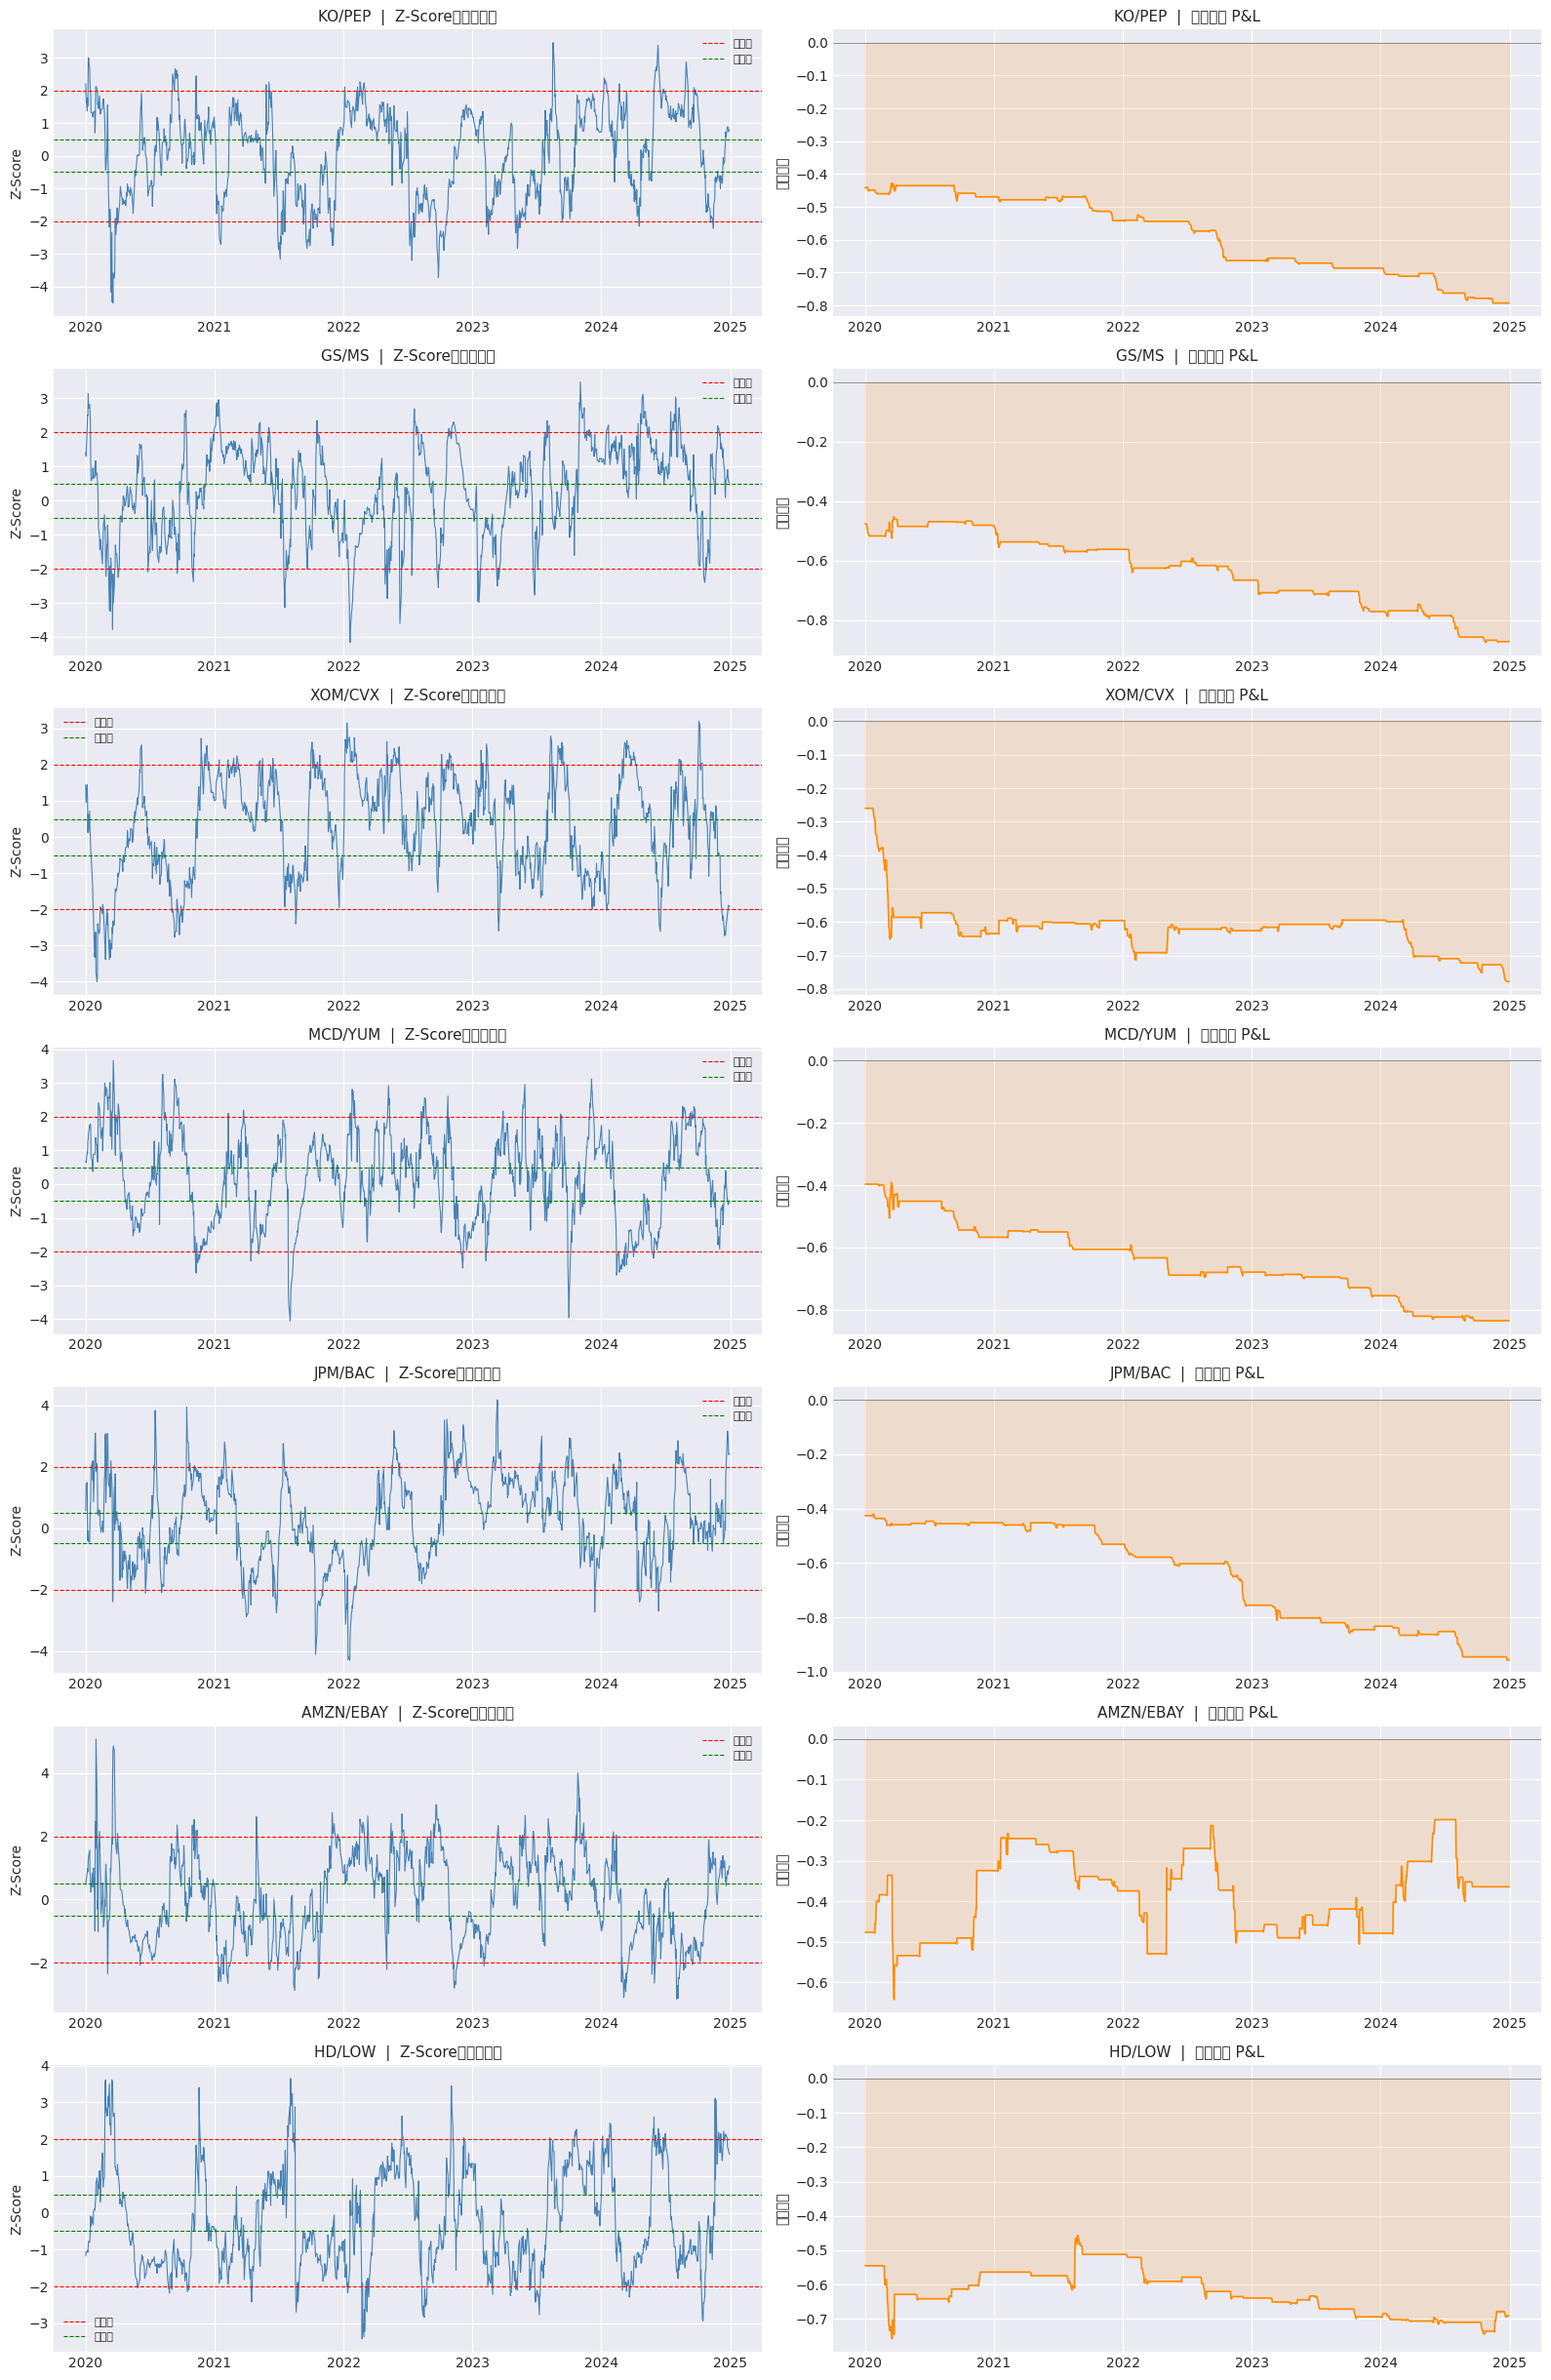

In [6]:
# ── 样本外回测（2020–2024）：所有候选对 ─────────────────────
oos_start = '2020-01-01'
fig, axes = plt.subplots(len(CANDIDATE_PAIRS), 2, figsize=(16, 3.5 * len(CANDIDATE_PAIRS)))
all_stats = []

for idx, (a, b) in enumerate(CANDIDATE_PAIRS):
    if a not in log_prices.columns or b not in log_prices.columns:
        continue
    info = results.get((a, b), {})
    beta = info.get('beta', 1.0)   # 用样本内估计的对冲比率

    res = backtest_pair(a, b, beta, log_prices)
    oos = res.loc[oos_start:]

    stats = performance_stats(oos['net_pnl'], f"{a}/{b} 样本外 2020–2024")
    stats['pair'] = f"{a}/{b}"
    all_stats.append(stats)

    ax1, ax2 = axes[idx]
    ax1.plot(oos.index, oos['zscore'], color='steelblue', lw=0.8)
    ax1.axhline( ZSCORE_ENTRY, color='red',   ls='--', lw=0.8, label='入场线')
    ax1.axhline(-ZSCORE_ENTRY, color='red',   ls='--', lw=0.8)
    ax1.axhline( ZSCORE_EXIT,  color='green', ls='--', lw=0.8, label='离场线')
    ax1.axhline(-ZSCORE_EXIT,  color='green', ls='--', lw=0.8)
    ax1.set_title(f"{a}/{b}  |  Z-Score（样本外）", fontsize=11)
    ax1.legend(fontsize=8)
    ax1.set_ylabel('Z-Score')

    ax2.plot(oos.index, oos['equity'], color='darkorange', lw=1.2)
    ax2.fill_between(oos.index, oos['equity'], alpha=0.15, color='darkorange')
    ax2.axhline(0, color='grey', lw=0.6)
    ax2.set_title(f"{a}/{b}  |  累计对数 P&L", fontsize=11)
    ax2.set_ylabel('累计收益')

plt.tight_layout()
plt.savefig('../assets/pairs_trading_results.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# ── 绩效汇总表 ──────────────────────────────────────────────
summary = pd.DataFrame(all_stats).set_index('pair')
summary['ann_ret'] = summary['ann_ret'].map('{:.2%}'.format)
summary['ann_vol'] = summary['ann_vol'].map('{:.2%}'.format)
summary['sharpe']  = summary['sharpe'].map('{:.3f}'.format)
summary['max_dd']  = summary['max_dd'].map('{:.2%}'.format)
summary.columns    = ['年化收益', '年化波动', '夏普比率', '最大回撤']
print("\n样本外绩效汇总（2020–2024）")
print(summary.to_string())


样本外绩效汇总（2020–2024）
              年化收益    年化波动    夏普比率     最大回撤
pair                                       
KO/PEP      -7.06%   3.82%  -1.846  -36.43%
GS/MS       -7.93%   6.19%  -1.282  -42.11%
XOM/CVX    -10.38%  10.00%  -1.038  -51.79%
MCD/YUM     -8.79%   7.46%  -1.178  -44.47%
JPM/BAC    -10.66%   5.37%  -1.983  -53.70%
AMZN/EBAY    2.25%  22.05%   0.102  -30.70%
HD/LOW      -2.92%  10.50%  -0.278  -28.71%


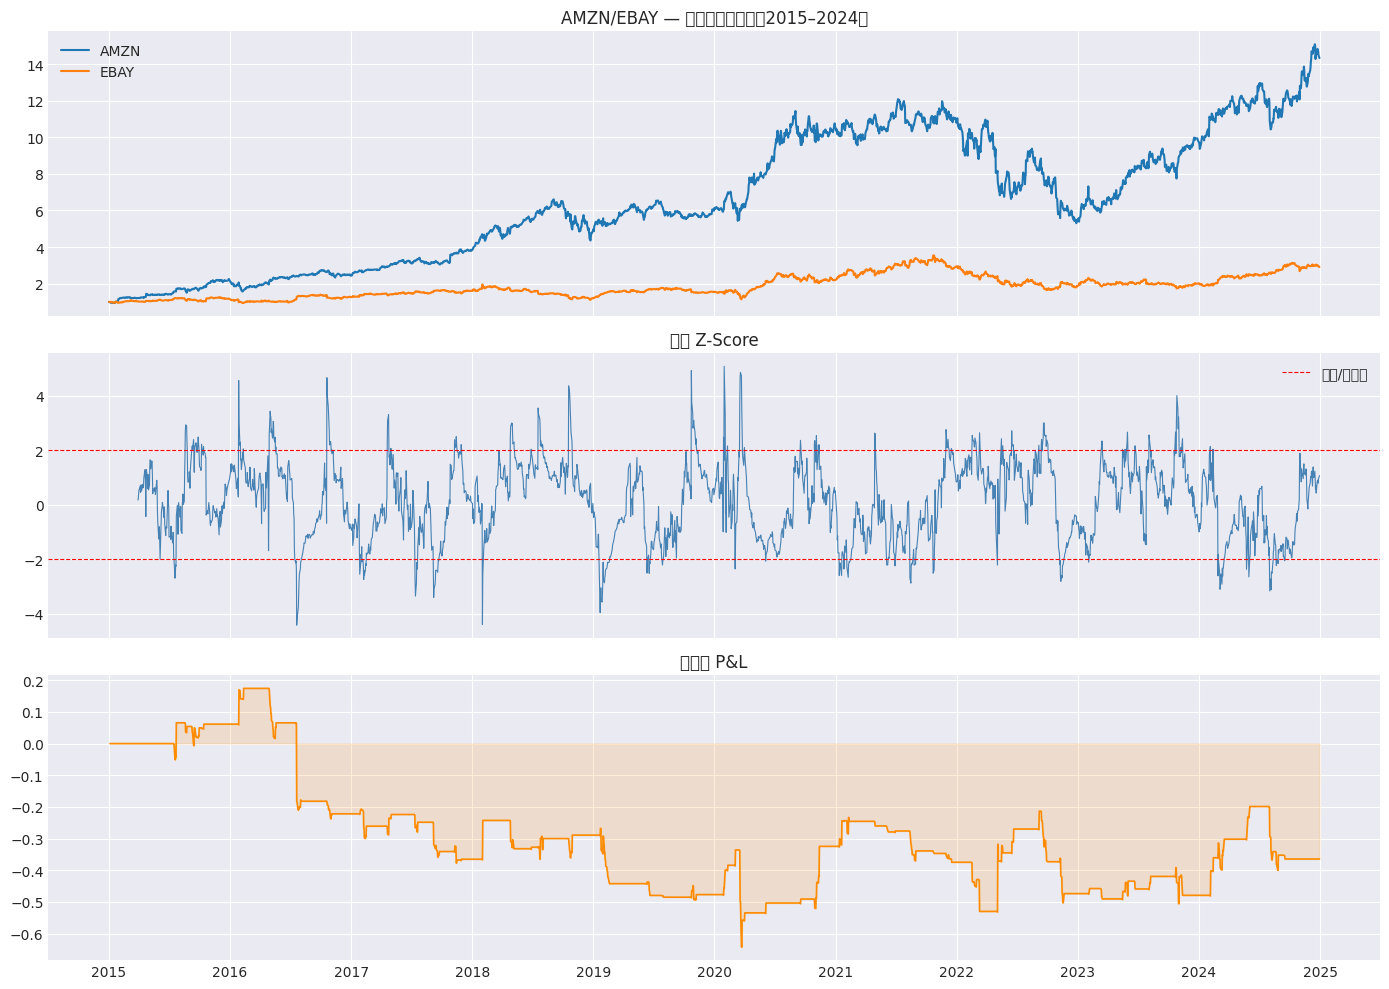


  AMZN/EBAY 全周期（2015–2024）
  年化收益率  : -3.65%
  年化波动率  : 20.50%
  夏普比率    : -0.178
  最大回撤    : -81.73%
  活跃交易日  : 395


{'ann_ret': np.float64(-0.03653702724515197),
 'ann_vol': np.float64(0.20501771797853424),
 'sharpe': np.float64(-0.17821399830905085),
 'max_dd': np.float64(-0.8173071427916068)}

In [8]:
# ── 最佳股票对深度分析 ─────────────────────────────────────
best_pair_name = max(all_stats, key=lambda x: float(x['sharpe']))
a, b = best_pair_name['pair'].split('/')
beta = results[(a, b)]['beta']
res = backtest_pair(a, b, beta, log_prices)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(res.index, np.exp(log_prices[a]) / np.exp(log_prices[a]).iloc[0], label=a)
axes[0].plot(res.index, np.exp(log_prices[b]) / np.exp(log_prices[b]).iloc[0], label=b)
axes[0].set_title(f"{a}/{b} — 归一化价格对比（2015–2024）")
axes[0].legend()

axes[1].plot(res.index, res['zscore'], color='steelblue', lw=0.8)
axes[1].axhline( ZSCORE_ENTRY, color='red', ls='--', lw=0.8, label='入场/止损线')
axes[1].axhline(-ZSCORE_ENTRY, color='red', ls='--', lw=0.8)
axes[1].set_title('价差 Z-Score')
axes[1].legend()

axes[2].plot(res.index, res['equity'], color='darkorange', lw=1.2)
axes[2].fill_between(res.index, res['equity'], alpha=0.15, color='darkorange')
axes[2].set_title('累计净 P&L')

plt.tight_layout()
plt.show()
performance_stats(res['net_pnl'], f"{a}/{b} 全周期（2015–2024）")